# Combination profile plots — France 2022 nuclear damage
Plots using `plot_combination_profile` for the FR 2022 nuclear damage scenario.

In [40]:
import sys
import numpy as np
import pandas as pd
import xarray as xr
import yaml
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from pathlib import Path
from functools import reduce

In [41]:
root = Path.cwd()
pypsa_eur_root = root.parent.parent
pypsa_eur_scripts = pypsa_eur_root / "scripts"

sys.path.insert(0, str(pypsa_eur_root))
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

In [42]:
from plot_combo import plot_combination_profile, build_storage_dict, format_ts_df, format_ts_diff_df
from scripts.build_damage_profiles.build_nuclear_damage_profiles import load_nuclear_plants

In [43]:
CONFIG_NAME = "2022-FR"
YEAR        = 2022
CLUSTERS    = 5

_results = pypsa_eur_root / "results" / CONFIG_NAME

SCENARIO_VARIANTS = {
    "cap": f"weather_year_{YEAR}_nuc_cap",
    "dis": f"weather_year_{YEAR}_nuc_dis",
}

NETWORK_PATHS = {
    "base":     _results / f"weather_year_{YEAR}_nuc_dis"  / "networks" / "base_s_5_elec_.nc",
    "base_cap": _results / f"weather_year_{YEAR}_nuc_base" / "networks" / "base_s_5_elec_.nc",
    "base_dis": _results / f"weather_year_{YEAR}_nuc_base" / "networks" / "base_s_5_elec__op.nc",
    "cap":      _results / f"weather_year_{YEAR}_nuc_cap"  / "networks" / "base_s_5_elec_.nc",
    "cap_op": _results / f"weather_year_{YEAR}_nuc_cap" / "networks" / "base_s_5_elec__op.nc",
    "dis":      _results / f"weather_year_{YEAR}_nuc_dis"  / "networks" / "base_s_5_elec__damaged-dispatch.nc",
}

In [44]:
networks = {label: pypsa.Network(path) for label, path in NETWORK_PATHS.items()}
nc       = pypsa.NetworkCollection(list(networks.values()), index=list(networks.keys()))

_color_overrides = {
    "load_shedding": "darkred",
    "oil":           "dimgray",
    "load":          "#4a4a4a",
}

for n in networks.values():
    if "" in n.carriers.index:
        n.carriers = n.carriers.rename(index={"": "load"})
        for attr in ["generators", "loads", "links", "storage_units", "stores"]:
            df = getattr(n, attr)
            if not df.empty and "carrier" in df.columns:
                df.loc[df["carrier"] == "", "carrier"] = "load"
    for carrier, color in _color_overrides.items():
        if carrier in n.carriers.index:
            n.carriers.loc[carrier, "color"] = color
    remaining = n.carriers[n.carriers.color.isna() | n.carriers.color.eq("")].index
    n.carriers.loc[remaining, "color"] = "lightgrey"

color_map = networks["base_dis"].carriers.color.to_dict()

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current:

In [45]:
SUP_CARRIERS    = ['biomass', 'nuclear', 'offwind-ac', 'offwind-dc', 'onwind',
                   'solar', 'solar-hsat', 'load_shedding', 'ror', 'hydro']
CHARGE_CARRIERS = ['H2 electrolysis', 'H2 fuel cell', 'battery', 'PHS']
STOR_CARRIERS   = ['H2 fuel cell']

carrier_order = [
    'nuclear', 'biomass', 'ror', 'offwind-ac', 'offwind-dc', 'onwind',
    'solar', 'solar-hsat', 'load_shedding', 'AC', 'H2 electrolysis',
    'H2 fuel cell', '', 'battery', 'hydro', 'PHS', 'H2',
]

In [46]:
# Load scenario damage data (only needed for PEL plots)
def load_scenario(base_dir):
    """Load powerplants and damage dataframes for a scenario directory."""
    powerplants_df = load_nuclear_plants(base_dir / f"powerplants_s_{CLUSTERS}.csv")
    damage_df      = xr.open_dataset(base_dir / "damage_profiles" / "nuclear_damage_plants.nc")["profile"].to_pandas()
    return {"powerplants_df": powerplants_df, "damage_df": damage_df}

_base_dir = pypsa_eur_root / "resources" / CONFIG_NAME
scenarios  = {
    label: load_scenario(_base_dir / subdir)
    for label, subdir in SCENARIO_VARIANTS.items()
}

# alias: cap_op shares the same damage scenario as cap
scenarios["cap_op"] = scenarios["cap"]

cf_fixed_factor = 0.616

In [47]:
def _aggregate(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    if freq == "h":
        return df
    if freq == "total":
        return pd.DataFrame([df.sum()], index=pd.Index([df.index[0]]))
    return df.resample(freq).sum()


def compute_eoh_nuclear(
    damage_df: pd.DataFrame,
    powerplants_df: pd.DataFrame,
    date_range: tuple | None = None,
    freq: str = "MS",
    granularity: str = "fleet",
) -> pd.DataFrame:
    """
    Equivalent outage hours for nuclear.

    EOH = capacity-weighted sum of hourly damage fractions per period.

    Parameters
    ----------
    damage_df      : plant-level damage fractions (time × plant), values in [0, 1]
    powerplants_df : must have columns Name, bus, Capacity
    date_range     : optional (start, end) ISO strings
    freq           : "h" | "W" | "MS" | "total"
    granularity    : "plant" | "bus" | "fleet"
    """
    pp = powerplants_df[powerplants_df["Name"].isin(damage_df.columns)].copy()
    capacities = pp.set_index("Name")["Capacity"]
    dmg = damage_df[pp["Name"].values].copy()
    if date_range is not None:
        dmg = dmg.loc[date_range[0]:date_range[1]]

    if granularity == "plant":
        return _aggregate(dmg, freq)

    if granularity == "bus":
        bus_map = pp.set_index("Name")["bus"]
        bus_dfs = {}
        for bus, group in pp.groupby("bus"):
            caps = group.set_index("Name")["Capacity"]
            bus_dfs[bus] = dmg[caps.index].mul(caps, axis=1).sum(axis=1) / caps.sum()
        return _aggregate(pd.DataFrame(bus_dfs), freq)

    # fleet
    fleet = dmg.mul(capacities, axis=1).sum(axis=1) / capacities.sum()
    return _aggregate(fleet.rename("fleet").to_frame(), freq)


def compute_potential_energy_loss_nuclear(
    damage_df: pd.DataFrame,
    powerplants_df: pd.DataFrame,
    cf_fixed: float = cf_fixed_factor,
    date_range: tuple | None = None,
    freq: str = "MS",
    granularity: str = "fleet",
) -> pd.DataFrame:
    """
    Potential energy loss (MWh) for nuclear.

    PEL = damage_fraction × cf_fixed × p_nom, aggregated per period.
    cf_fixed is the nuclear equivalent of p_max_pu in the wind formulation.

    Parameters
    ----------
    damage_df      : plant-level damage fractions (time × plant), values in [0, 1]
    powerplants_df : must have columns Name, bus, Capacity
    cf_fixed       : baseline capacity factor (analogous to p_max_pu)
    date_range     : optional (start, end) ISO strings
    freq           : "h" | "W" | "MS" | "total"
    granularity    : "plant" | "bus" | "fleet"
    """
    pp = powerplants_df[powerplants_df["Name"].isin(damage_df.columns)].copy()
    capacities = pp.set_index("Name")["Capacity"]
    dmg = damage_df[pp["Name"].values].copy()
    if date_range is not None:
        dmg = dmg.loc[date_range[0]:date_range[1]]

    pel_plant = dmg.mul(capacities * cf_fixed, axis=1)

    if granularity == "plant":
        return _aggregate(pel_plant, freq)

    if granularity == "bus":
        bus_map = pp.set_index("Name")["bus"]
        pel_bus = pel_plant.T.groupby(bus_map).sum().T
        return _aggregate(pel_bus, freq)

    # fleet
    return _aggregate(pel_plant.sum(axis=1).rename("fleet").to_frame(), freq)


In [16]:
# ── Helper functions ─────────────────────────────────────────────────────────

def _pivot(ts_eb, network, carrier, bus_carrier):
    mask = (
        (ts_eb["network"]     == network) &
        (ts_eb["carrier"]     == carrier) &
        (ts_eb["bus_carrier"] == bus_carrier)
    )
    return (
        ts_eb[mask]
        .pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum")
        .fillna(0)
    )

def get_soc_by_bus(n, carrier):
    store_idx = n.stores.index[n.stores.carrier == carrier]
    if not store_idx.empty:
        df = n.stores_t.e[store_idx].copy()
        df.columns = n.stores.loc[store_idx, "bus"]
        return df.T.groupby(level=0).sum().T
    su_idx = n.storage_units.index[n.storage_units.carrier == carrier]
    if not su_idx.empty:
        df = n.storage_units_t.state_of_charge[su_idx].copy()
        df.columns = n.storage_units.loc[su_idx, "bus"]
        return df.T.groupby(level=0).sum().T
    raise ValueError(f"No Store or StorageUnit found for carrier '{carrier}'")

def _fleet_price(n):
    ac     = n.buses.index[n.buses.carrier == "AC"]
    prices = n.buses_t.marginal_price[ac]
    load_w = n.loads_t.p_set.reindex(columns=ac).fillna(0)
    return (prices * load_w).sum(axis=1) / load_w.sum(axis=1).replace(0, np.nan)

def _aggregate(df, freq):
    if freq == "h":
        return df
    if freq == "total":
        return pd.DataFrame([df.sum()], index=pd.Index([df.index[0]]))
    return df.resample(freq).sum()

def compute_potential_energy_loss_nuclear(
    damage_df, powerplants_df, cf_fixed=cf_fixed_factor,
    date_range=None, freq="MS", granularity="fleet",
):
    pp         = powerplants_df[powerplants_df["Name"].isin(damage_df.columns)].copy()
    capacities = pp.set_index("Name")["Capacity"]
    dmg        = damage_df[pp["Name"].values].copy()
    if date_range is not None:
        dmg = dmg.loc[date_range[0]:date_range[1]]
    pel_plant = dmg.mul(capacities * cf_fixed, axis=1)
    if granularity == "plant":
        return _aggregate(pel_plant, freq)
    if granularity == "bus":
        bus_map = pp.set_index("Name")["bus"]
        return _aggregate(pel_plant.T.groupby(bus_map).sum().T, freq)
    return _aggregate(pel_plant.sum(axis=1).rename("fleet").to_frame(), freq)

In [17]:
def prepare_combo_data(base, scen, *, nc, scenarios=None):
    n_base = nc.networks[base]
    n_scen = nc.networks[scen]

    EXCLUDE = ["coal", "ocgt", "ccgt"]
    ts_eb   = format_ts_df(nc, stat="energy_balance")
    ts_eb   = ts_eb[~ts_eb["carrier"].isin(EXCLUDE)]
    ts_diff = format_ts_diff_df(nc.networks, stat="energy_balance", base=base)

    def p(network, carrier, bus_carrier):
        return _pivot(ts_eb, network, carrier, bus_carrier)

    ls_df      = p(scen, "load_shedding", "AC")
    ls_df[ls_df < 0.001] = 0

    fc_df      = p(scen, "H2 fuel cell", "AC")
    fc_diff_df = fc_df - p(base, "H2 fuel cell", "AC")

    elec_scen_df = p(scen, "H2 electrolysis", "H2")
    elec_diff_df = elec_scen_df - p(base, "H2 electrolysis", "H2")

    line_df      = p(scen, "AC", "AC")
    line_base_df = p(base, "AC", "AC")
    line_diff_df = line_df - line_base_df

    soc_scen        = get_soc_by_bus(n_scen, "H2")
    soc_base        = get_soc_by_bus(n_base, "H2")
    soc_diff_df     = soc_scen - soc_base
    h2_e_nom_by_bus = (
        n_scen.stores[n_scen.stores.carrier == "H2"]
        .groupby("bus")["e_nom_opt"].sum()
    )

    price_scen  = _fleet_price(n_scen)
    price_base_ = _fleet_price(n_base)
    price_fleet = price_scen.to_frame("fleet")
    price_diff  = (price_scen - price_base_).to_frame("fleet")

    if scenarios is not None and scen in scenarios:
        _s = scenarios[scen]
        pel_dict_nuc = {
            "nuclear": compute_potential_energy_loss_nuclear(
                _s["damage_df"], _s["powerplants_df"], freq="h", granularity="bus",
            )
        }
    else:
        pel_dict_nuc = {}

    storage_dict = build_storage_dict(nc, scen)

    return {
        "ts_diff":         ts_diff,
        "ls_df":           ls_df,
        "fc_df":           fc_df,
        "fc_diff_df":      fc_diff_df,
        "elec_scen_df":    elec_scen_df,
        "elec_diff_df":    elec_diff_df,
        "line_df":         line_df,
        "line_base_df":    line_base_df,
        "line_diff_df":    line_diff_df,
        "soc_scen":        soc_scen,
        "soc_base":        soc_base,
        "soc_diff_df":     soc_diff_df,
        "h2_e_nom_by_bus": h2_e_nom_by_bus,
        "price_fleet":     price_fleet,
        "price_diff":      price_diff,
        "pel_dict_nuc":    pel_dict_nuc,
        "storage_dict":    storage_dict,
    }

## Plots

## Base

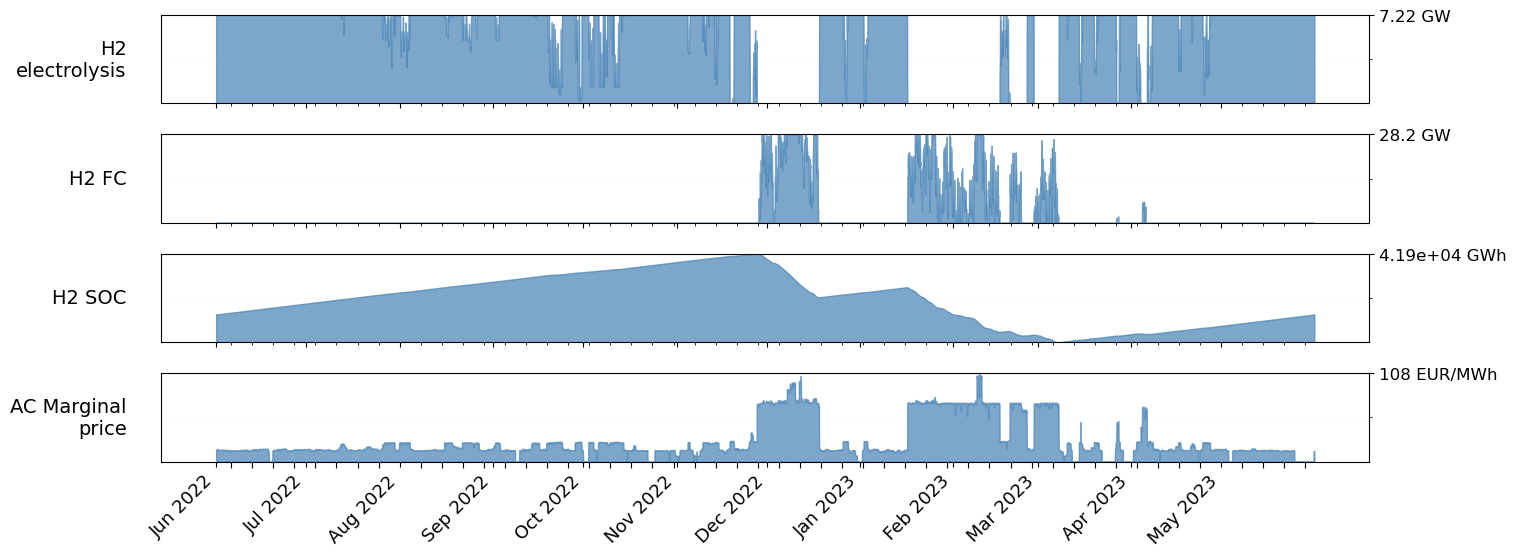

In [10]:
# Base network — H2 electrolysis, SOC, price (no diff)
base = "base_dis"
scen = "base_dis"

d = prepare_combo_data(base, scen, nc=nc, scenarios=None)

fig, axes = plot_combination_profile(
    carrier_groups={
        "nuclear": "nuclear",
        "biomass": "biomass",
        "hydro":   "hydro",
    },
    components={
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "AC Marginal\nprice": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-06-01", f"{YEAR+1}-05-31"),
    show_day_ticks=False,
    title=None,
    fontsize=14,
    label_gap=25,
)

## Damaged dispatch

In [68]:
15/(0.69*0.5)

43.47826086956522

In [56]:
peak_t = d['price_fleet'].idxmax()
n = networks["base_dis"]
print(n.buses_t.marginal_price.loc[peak_t])


name                      FR0 0       FR0 1       FR0 2       FR0 3  \
snapshot                                                              
2023-02-09 17:00:00  111.111239  110.593632  106.788301  101.592608   

name                     FR0 4   FR0 0 H2   FR0 1 H2   FR0 2 H2   FR0 3 H2  \
snapshot                                                                     
2023-02-09 17:00:00  109.26434  35.839403  35.841294  35.985048  35.537525   

name                  FR0 4 H2  
snapshot                        
2023-02-09 17:00:00  35.614641  


In [61]:
peak_t = d['price_fleet'].idxmax()
n = networks["dis"]
print(n.buses_t.marginal_price.loc[peak_t])


name                        FR0 0         FR0 1         FR0 2         FR0 3  \
snapshot                                                                      
2023-02-09 17:00:00  10000.009882  10000.010324  10000.010146  10000.003712   

name                        FR0 4   FR0 0 H2    FR0 1 H2    FR0 2 H2  \
snapshot                                                               
2023-02-09 17:00:00  10000.010292  4794.2023  4795.20751  4799.97597   

name                    FR0 3 H2    FR0 4 H2  
snapshot                                      
2023-02-09 17:00:00  4732.583029  4778.34232  


In [70]:
peak_t = d['price_fleet'].idxmax()
n = networks["base_dis"]
print(n.buses_t.marginal_price.loc["2022-12-09 16:00":"2022-12-13 20:00"])

name                     FR0 0      FR0 1      FR0 2      FR0 3      FR0 4  \
snapshot                                                                     
2022-12-09 16:00:00  96.162832  96.162832  96.162777  96.162816  96.162709   
2022-12-09 17:00:00  96.162853  96.162859  96.162799  96.162818  96.162713   
2022-12-09 18:00:00  96.162828  96.162829  96.162781  96.162816  96.162701   
2022-12-09 19:00:00  96.162792  96.162786  96.162746  96.162812  96.162688   
2022-12-09 20:00:00  96.162740  96.162722  96.162673  96.162803  96.162668   
...                        ...        ...        ...        ...        ...   
2022-12-13 16:00:00  77.524922  77.462905  78.096302  77.699082  71.270830   
2022-12-13 17:00:00  77.525109  77.463125  78.096355  77.699089  71.270954   
2022-12-13 18:00:00  77.525047  77.463041  78.096329  77.699089  71.270885   
2022-12-13 19:00:00  77.524896  77.462836  78.096301  77.699088  71.270747   
2022-12-13 20:00:00  77.524887  77.462829  78.096284  77.699087 

In [ ]:
peak_t = d['price_fleet'].idxmax()
n = networks["base_dis"]
print(n.buses_t.marginal_price.loc["2022-12-09 16:00":"2022-12-13 20:00"])

name                     FR0 0      FR0 1      FR0 2      FR0 3      FR0 4  \
snapshot                                                                     
2022-12-09 16:00:00  96.162832  96.162832  96.162777  96.162816  96.162709   
2022-12-09 17:00:00  96.162853  96.162859  96.162799  96.162818  96.162713   
2022-12-09 18:00:00  96.162828  96.162829  96.162781  96.162816  96.162701   
2022-12-09 19:00:00  96.162792  96.162786  96.162746  96.162812  96.162688   
2022-12-09 20:00:00  96.162740  96.162722  96.162673  96.162803  96.162668   
...                        ...        ...        ...        ...        ...   
2022-12-13 16:00:00  77.524922  77.462905  78.096302  77.699082  71.270830   
2022-12-13 17:00:00  77.525109  77.463125  78.096355  77.699089  71.270954   
2022-12-13 18:00:00  77.525047  77.463041  78.096329  77.699089  71.270885   
2022-12-13 19:00:00  77.524896  77.462836  78.096301  77.699088  71.270747   
2022-12-13 20:00:00  77.524887  77.462829  78.096284  77.699087 

In [76]:
15.8/(0.7*0.5)

45.142857142857146

In [77]:
15.83/0.75

21.106666666666666

In [74]:
40/(0.75*0.96)

55.55555555555556

In [52]:
print(n.carriers.co2_emissions)



name
AC                 0.0000
DC                 0.0000
biomass            0.0000
oil                0.2571
nuclear            0.0000
lignite            0.4069
coal               0.3361
CCGT               0.1980
onwind             0.0000
offwind-ac         0.0000
offwind-dc         0.0000
solar-hsat         0.0000
solar              0.0000
hydro              0.0000
ror                0.0000
PHS                0.0000
battery            0.0000
H2                 0.0000
H2 fuel cell       0.0000
H2 electrolysis    0.0000
load               0.0000
Name: co2_emissions, dtype: float64


In [50]:
n = networks["base_cap"]
n.generators[["carrier", "marginal_cost"]].sort_values("marginal_cost", ascending=False).head(20)


,carrier,marginal_cost
name,,
FR0 4 oil,oil,157.533875
FR0 1 oil,oil,157.533459
FR0 4 CCGT,CCGT,52.662735
FR0 3 CCGT,CCGT,46.371803
FR0 0 CCGT,CCGT,45.679441
FR0 2 CCGT,CCGT,45.189829
FR0 1 CCGT,CCGT,45.091262
FR0 4 coal,coal,30.109627
FR0 0 coal,coal,30.109289


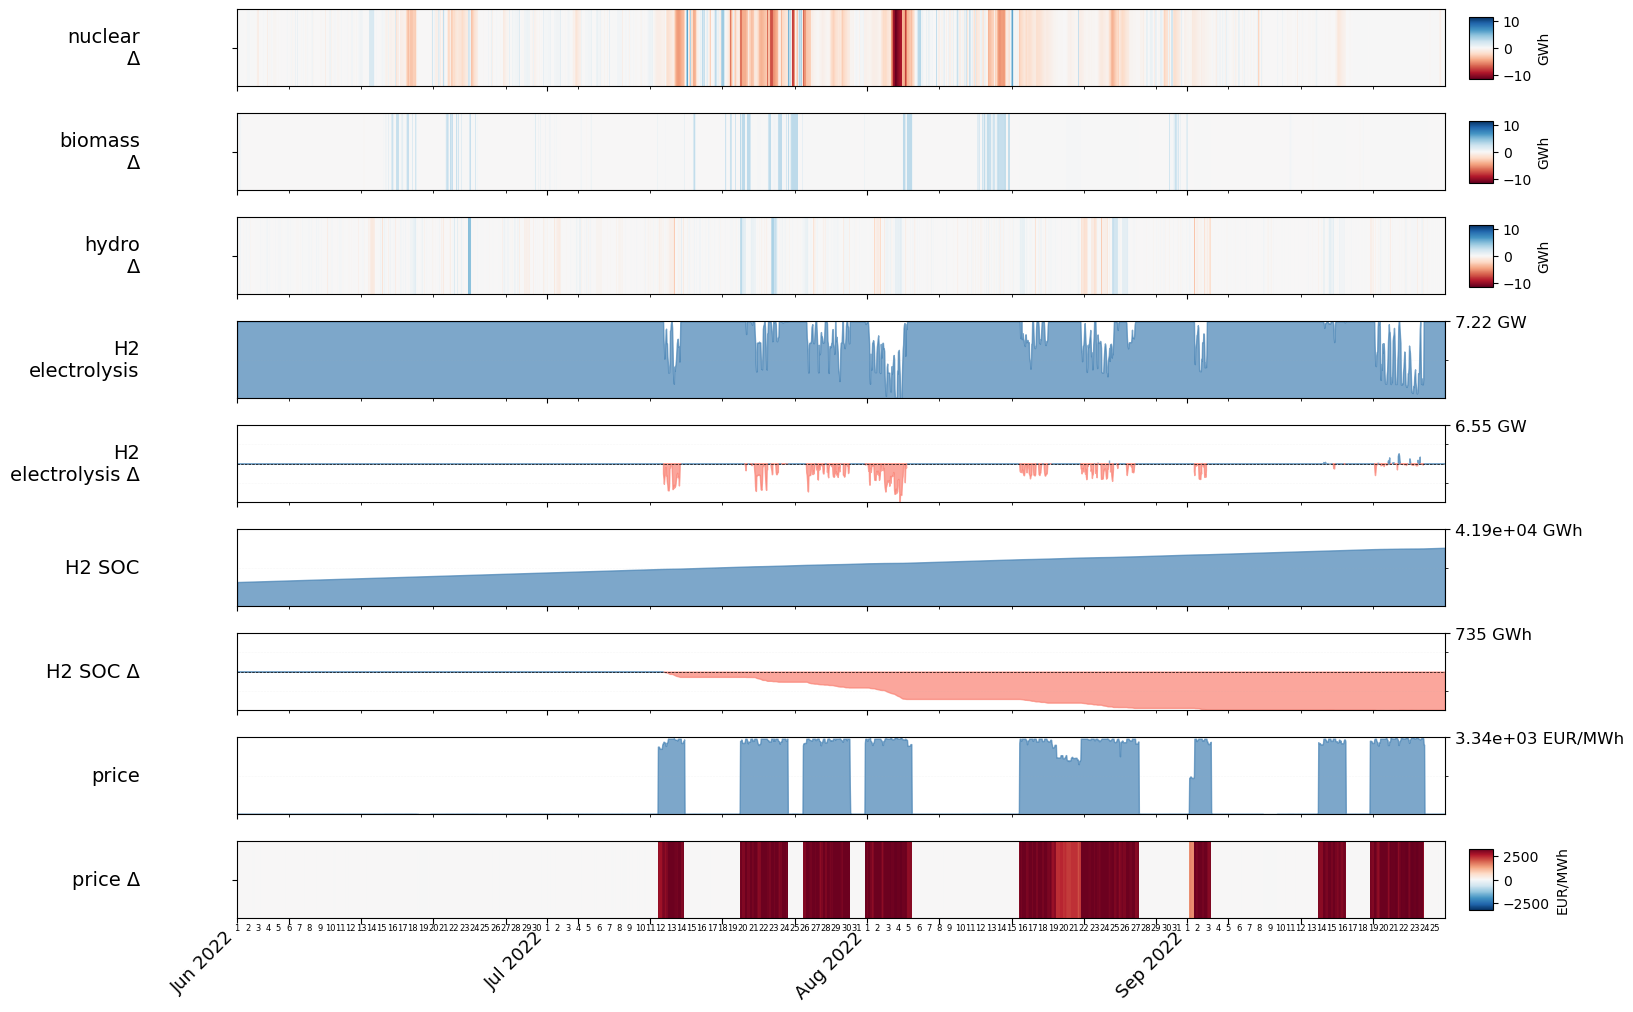

In [ ]:
# Damage scenario — H2 electrolysis, SOC, price with diffs
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={
        "nuclear": "nuclear",
        "biomass": "biomass",
        "hydro":   "hydro",
    },
    components={
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "nuclear", "row_height": 1.2,
        },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis \u0394": {
            "type": "direct", "data": d["elec_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "price": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-06-01", f"{YEAR}-09-25"),
    show_day_ticks=True,
    title=None,
    fontsize=14,
    label_gap=70,
)

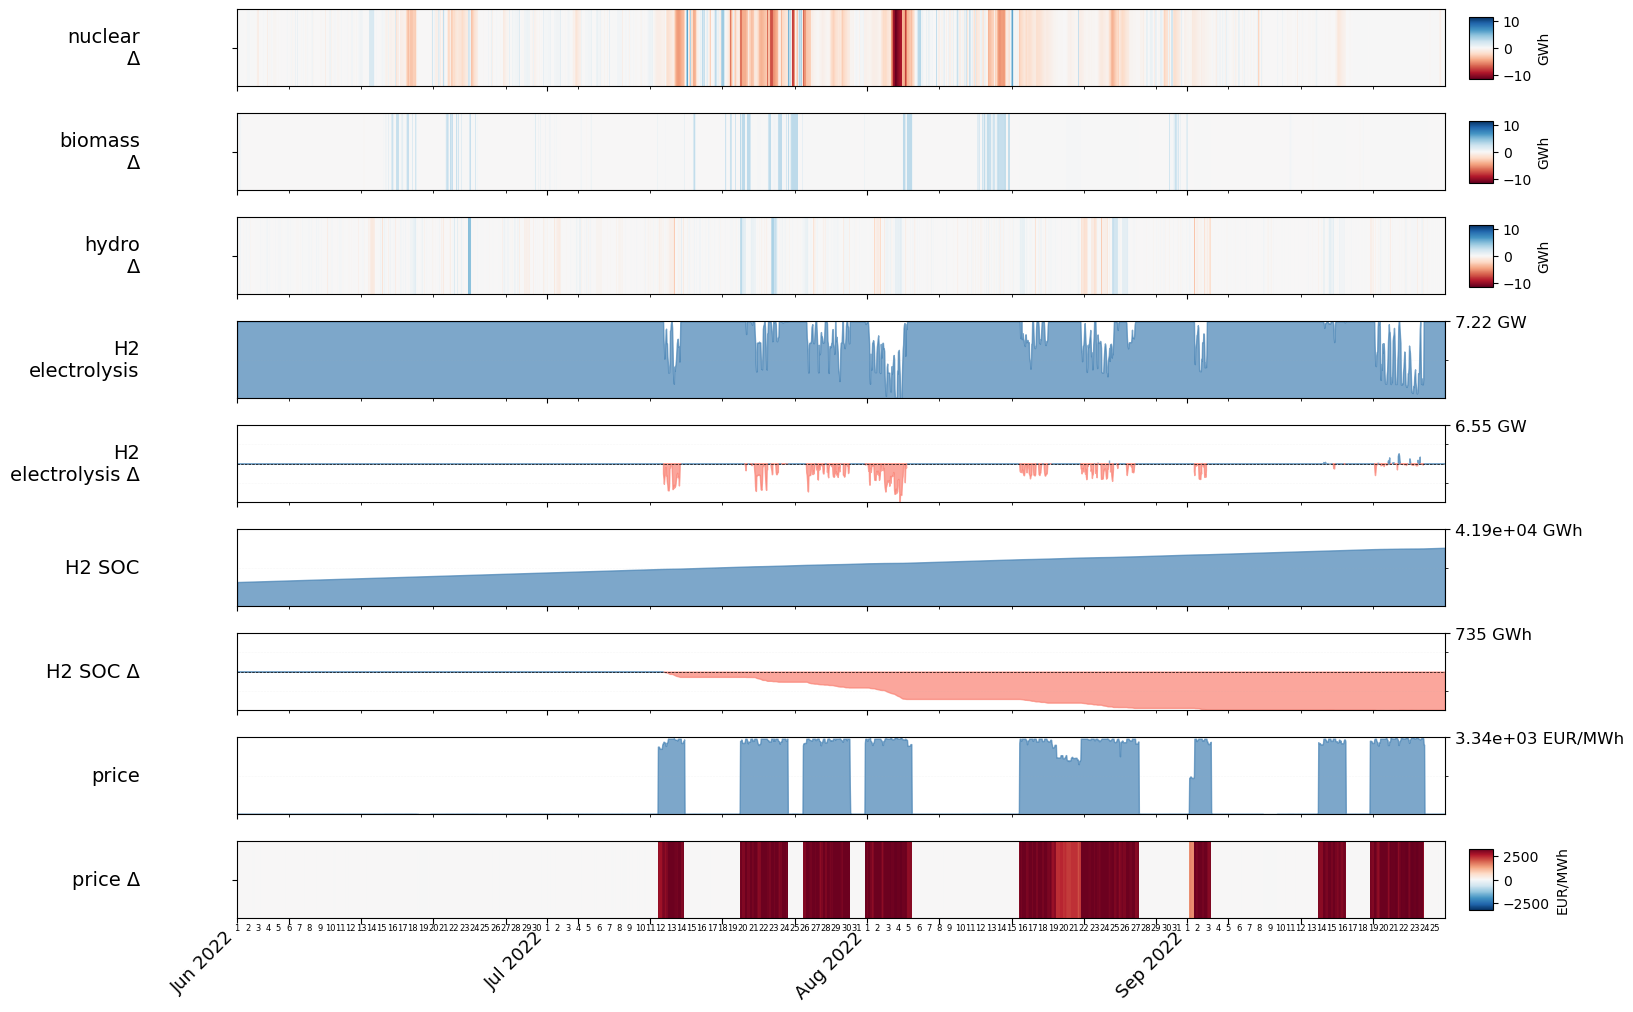

In [84]:
# Damage scenario — H2 electrolysis, SOC, price with diffs
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={
        "nuclear": "nuclear",
        "biomass": "biomass",
        "hydro":   "hydro",
    },
    components={
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "nuclear", "row_height": 1.2,
        },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis \u0394": {
            "type": "direct", "data": d["elec_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "price": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-06-01", f"{YEAR}-09-25"),
    show_day_ticks=True,
    title=None,
    fontsize=14,
    label_gap=70,
)

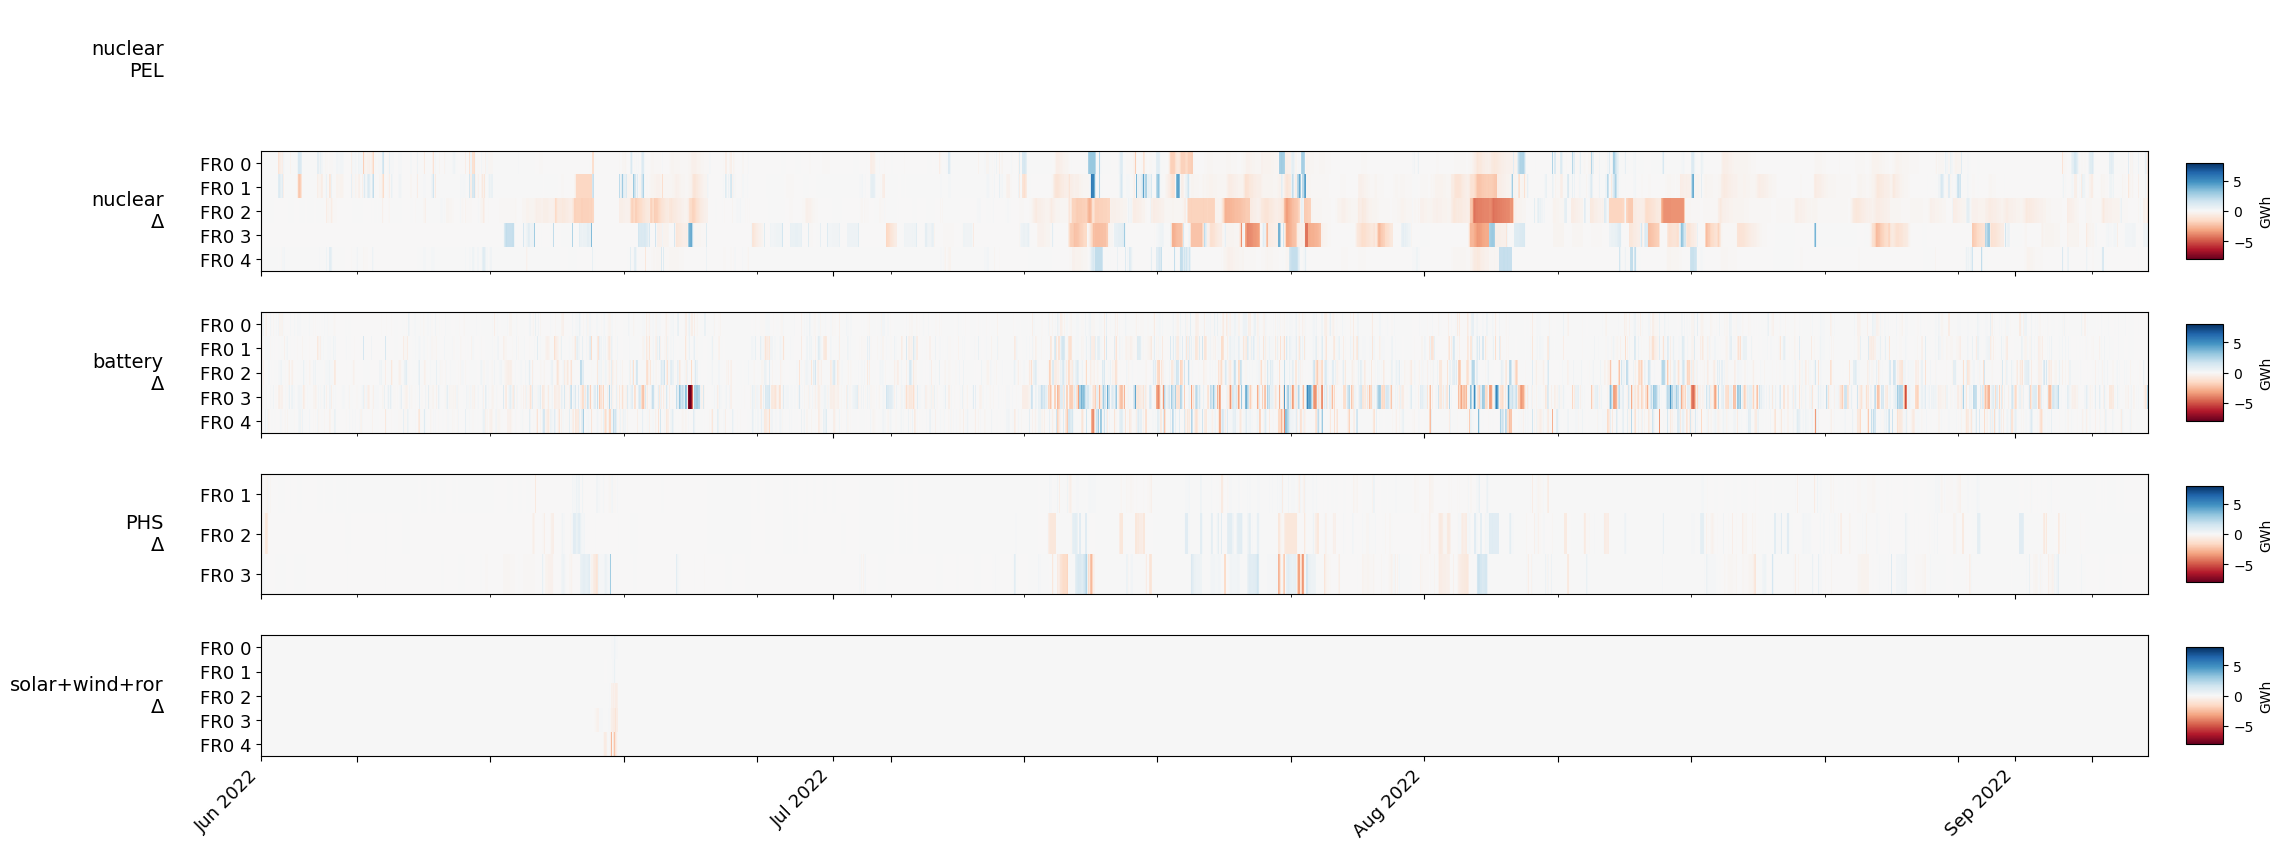

In [11]:
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={"nuclear": "nuclear",
                    # "biomass": "biomass",
                    # "hydro": "hydro",
                    "battery": "battery",
                    "PHS": "PHS",
                    # "ror": "ror",
                    "solar+wind+ror": ["solar","solar-hsat",'offwind-ac','offwind-dc','onwind', 'ror']
                    },
        components={
            "PEL": {
                "type": "carrier_dict", "data": d["pel_dict_nuc"],
                "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear",
            },
            "Δ": {
                "type": "ts_diff", "data": d["ts_diff"], "network": scen,
                "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear", "row_height": 1.8,
            },
            # "load shedding": {
            #     "type": "direct", "data": d["ls_df"],
            #     "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
            # },
            # "H2 FC": {
            #     "type": "direct", "data": d["fc_df"],
            #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 0.8,
            # },
            # "H2\nelectrolysis": {
            #     "type": "direct", "data": d["elec_scen_df"],
            #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 0.8,
            # },
            # "H2 elec diff": {
            #     "type": "direct", "data": d["elec_diff_df"],
            #     "render": "area", "symmetric": True,
            #     "color": "steelblue", "neg_color": "salmon",
            #     "multiplier": 1e-3, "unit": "GWh", "row_height": 0.6,
            # },
            # "H2 SOC": {
            #     "type": "direct", "data": d["soc_scen"],
            #     "render": "area", "symmetric": False,
            #     "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            #     "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 0.6,
            # },
            # "H2 SOC Δ": {
            #     "type": "direct", "data": d["soc_diff_df"],
            #     "render": "area", "symmetric": True,
            #     "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
            # },
            # "price": {
            #     "type": "direct", "data": d["price_fleet"],
            #     "render": "area", "unit": "EUR/MWh", "row_height": 0.6,
            # },
            # "price Δ": {
            #     "type": "direct", "data": d["price_diff"],
            #     "render": "heatmap", "cmap": "RdBu_r",
            #     "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
            # },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-06-01", f"{YEAR}-09-07"),
    title=None,
    fontsize=14,   # component names = 11, bus labels = 10, x ticks = 10, y ticks = 9
    label_gap=70,
    fig_width= 25
)

In [82]:
10000*(0.699*0.5*0.96*0.75)

2516.3999999999996

In [81]:
10000*(0.699*0.5)

3495.0

In [79]:
18.666666666666668/(0.7*0.5*0.96*0.75)

74.07407407407408

In [78]:
14/0.75

18.666666666666668

In [47]:
(10000)*0.7*0.5*0.96

3360.0

In [ ]:
# Nuclear PEL vs EB diff — per bus, summer
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={"nuclear": "nuclear"},
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_nuc"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear",
        },
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "nuclear", "row_height": 1.8,
        },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-06-01", f"{YEAR}-09-07"),
    title=None,
    fontsize=14,
    label_gap=70,
    fig_width=25,
)

In [ ]:
# All generators PEL + EB diff — full year, per bus
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={
        "nuclear": "nuclear",
        "biomass": "biomass",
        "hydro":   "hydro",
        "battery": "battery",
        "PHS":     "PHS",
        "ror":     "ror",
        "solar+wind": ["solar", "solar-hsat", "offwind-ac", "offwind-dc", "onwind"],
    },
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_nuc"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear",
        },
        "\u0394 EB": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear",
        },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-06-01", f"{YEAR}-11-27"),
    title=None,
)

In [ ]:
# Winter: hydro/solar/wind/storage with H2 and price diffs
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={
        "hydro":       "hydro",
        "solar+wind":  ["solar", "solar-hsat", "offwind-ac", "offwind-dc", "onwind"],
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        },
        "\u0394 dispatch": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "nuclear", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "H2 SOC \u0394": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True,
            "multiplier": 1e-3, "unit": "GWh",
            "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-12-01", f"{YEAR+1}-03-15"),
    title=None,
    fontsize=14,
    label_gap=25,
)

## Damaged Capacity

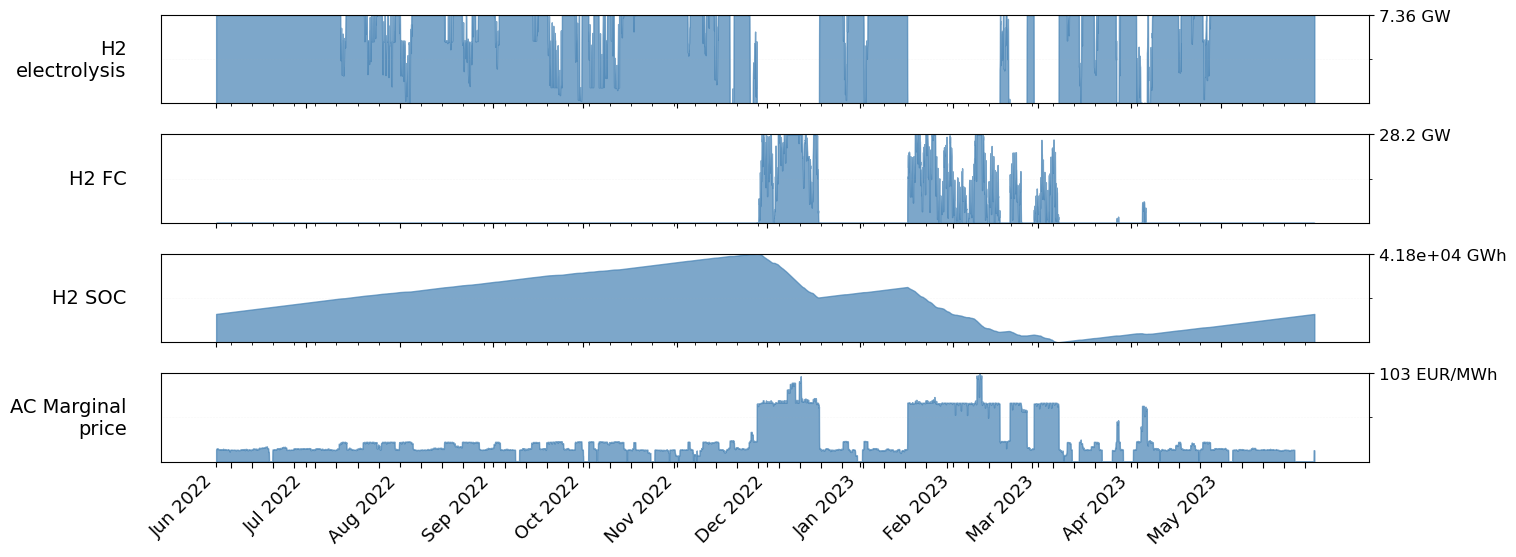

In [ ]:
# Base network — H2 electrolysis, SOC, price (no diff)
base = "cap_op"
scen = "cap_op"

d = prepare_combo_data(base, scen, nc=nc, scenarios=None)

fig, axes = plot_combination_profile(
    carrier_groups={
        "nuclear": "nuclear",
        "biomass": "biomass",
        "hydro":   "hydro",
    },
    components={
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        "AC Marginal\nprice": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-06-01", f"{YEAR+1}-05-31"),
    show_day_ticks=False,
    title=None,
    fontsize=14,
    label_gap=25,
)

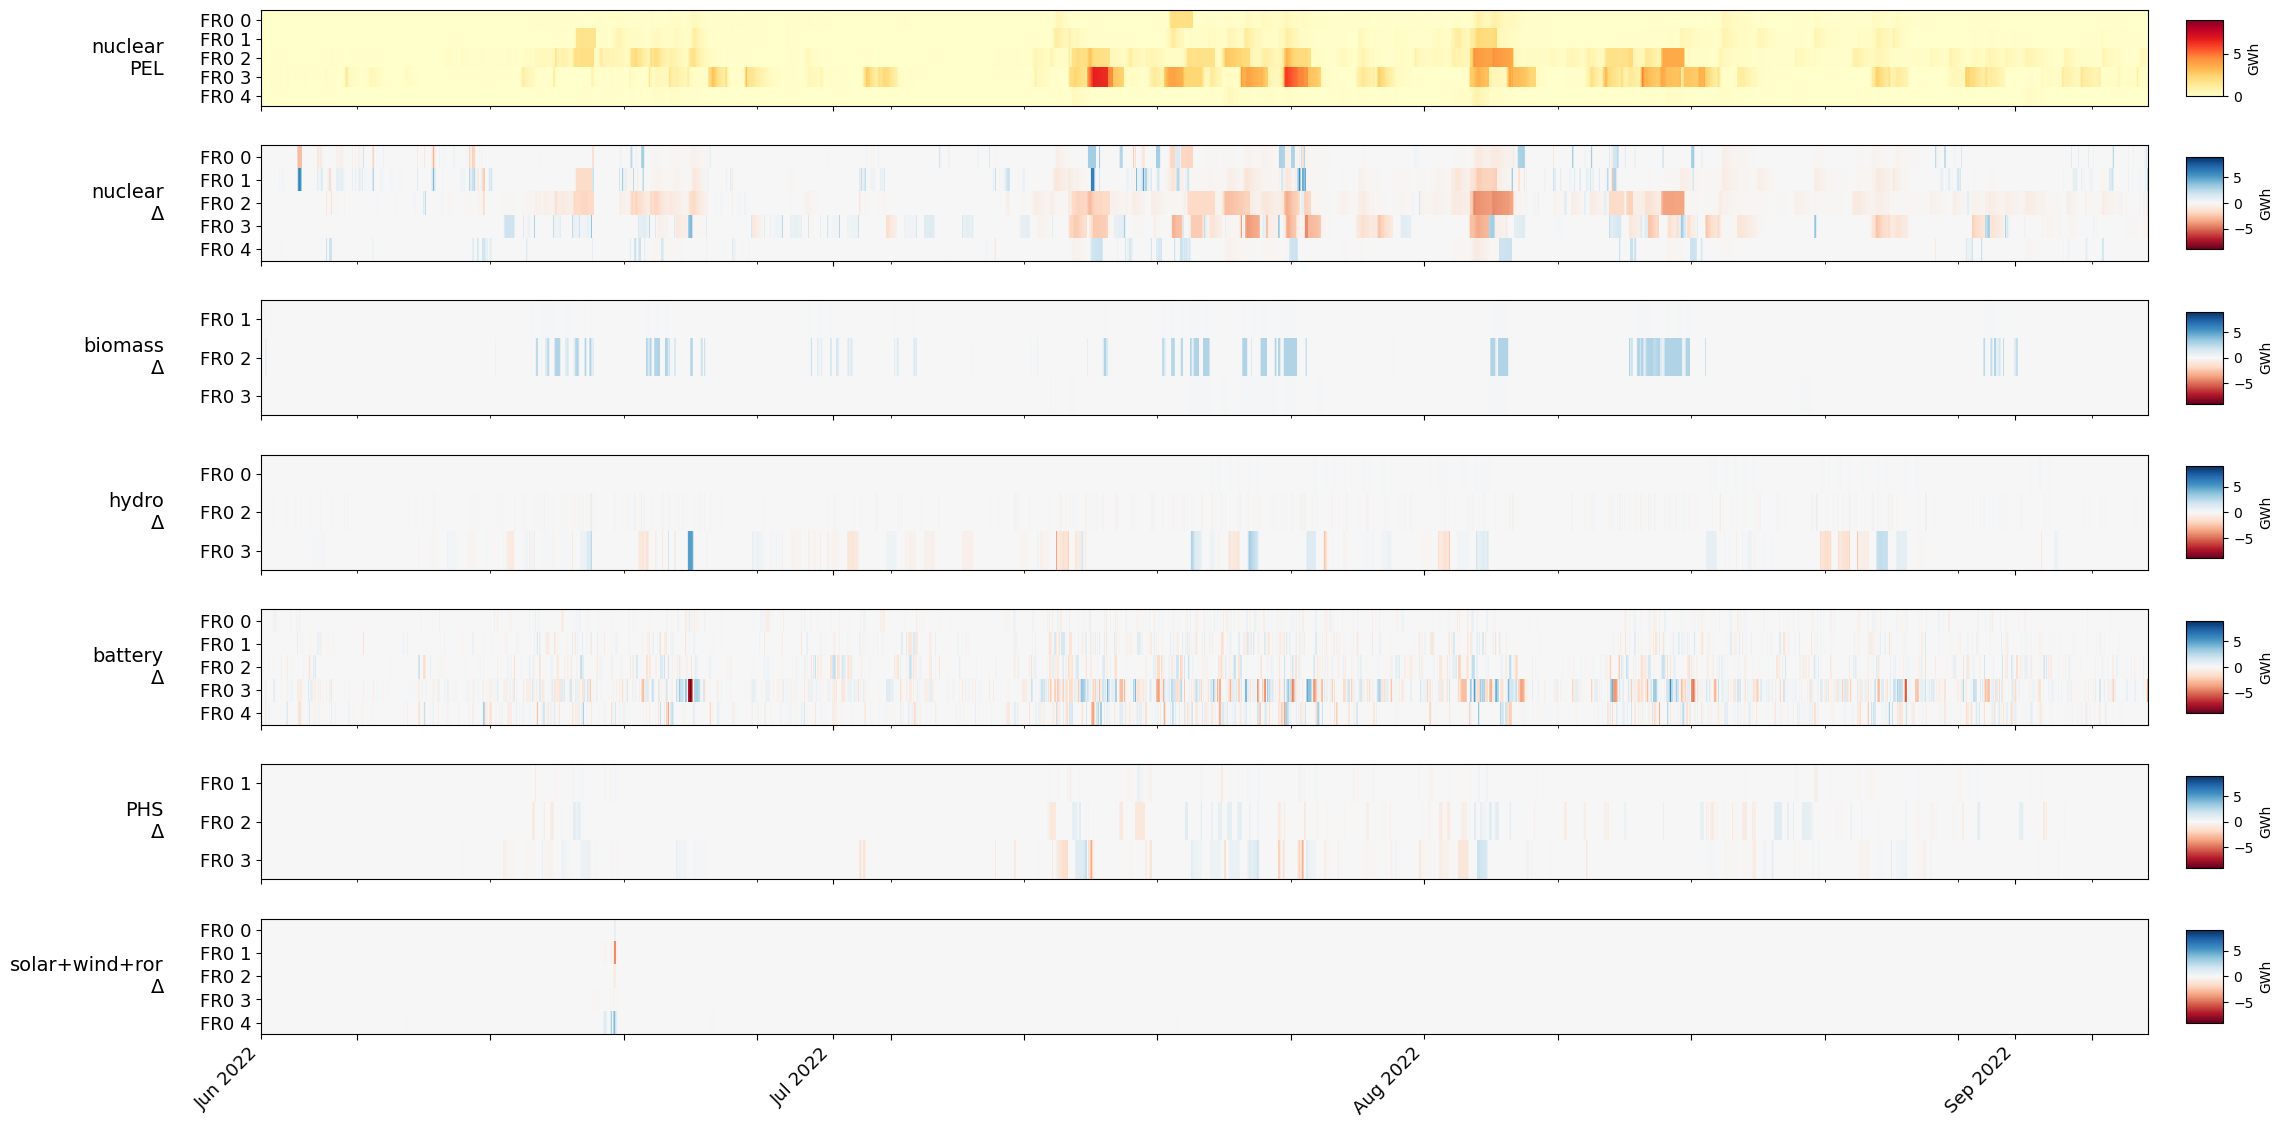

In [48]:
base = "base_dis"
scen = "cap_op"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={"nuclear": "nuclear",
                    "biomass": "biomass",
                    "hydro": "hydro",
                    "battery": "battery",
                    "PHS": "PHS",
                    # "ror": "ror",
                    "solar+wind+ror": ["solar","solar-hsat",'offwind-ac','offwind-dc','onwind', 'ror']
                    },
        components={
            "PEL": {
                "type": "carrier_dict", "data": d["pel_dict_nuc"],
                "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear",
            },
            "Δ": {
                "type": "ts_diff", "data": d["ts_diff"], "network": scen,
                "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear", "row_height": 1.8,
            },
            # "load shedding": {
            #     "type": "direct", "data": d["ls_df"],
            #     "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
            # },
            # "H2 FC": {
            #     "type": "direct", "data": d["fc_df"],
            #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 0.8,
            # },
            # "H2\nelectrolysis": {
            #     "type": "direct", "data": d["elec_scen_df"],
            #     "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 0.8,
            # },
            # "H2 elec diff": {
            #     "type": "direct", "data": d["elec_diff_df"],
            #     "render": "area", "symmetric": True,
            #     "color": "steelblue", "neg_color": "salmon",
            #     "multiplier": 1e-3, "unit": "GWh", "row_height": 0.6,
            # },
            # "H2 SOC": {
            #     "type": "direct", "data": d["soc_scen"],
            #     "render": "area", "symmetric": False,
            #     "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            #     "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 0.6,
            # },
            # "H2 SOC Δ": {
            #     "type": "direct", "data": d["soc_diff_df"],
            #     "render": "area", "symmetric": True,
            #     "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
            # },
            # "price": {
            #     "type": "direct", "data": d["price_fleet"],
            #     "render": "area", "unit": "EUR/MWh", "row_height": 0.6,
            # },
            # "price Δ": {
            #     "type": "direct", "data": d["price_diff"],
            #     "render": "heatmap", "cmap": "RdBu_r",
            #     "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
            # },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-06-01", f"{YEAR}-09-07"),
    title=None,
    fontsize=14,   # component names = 11, bus labels = 10, x ticks = 10, y ticks = 9
    label_gap=70,
    fig_width= 25
)

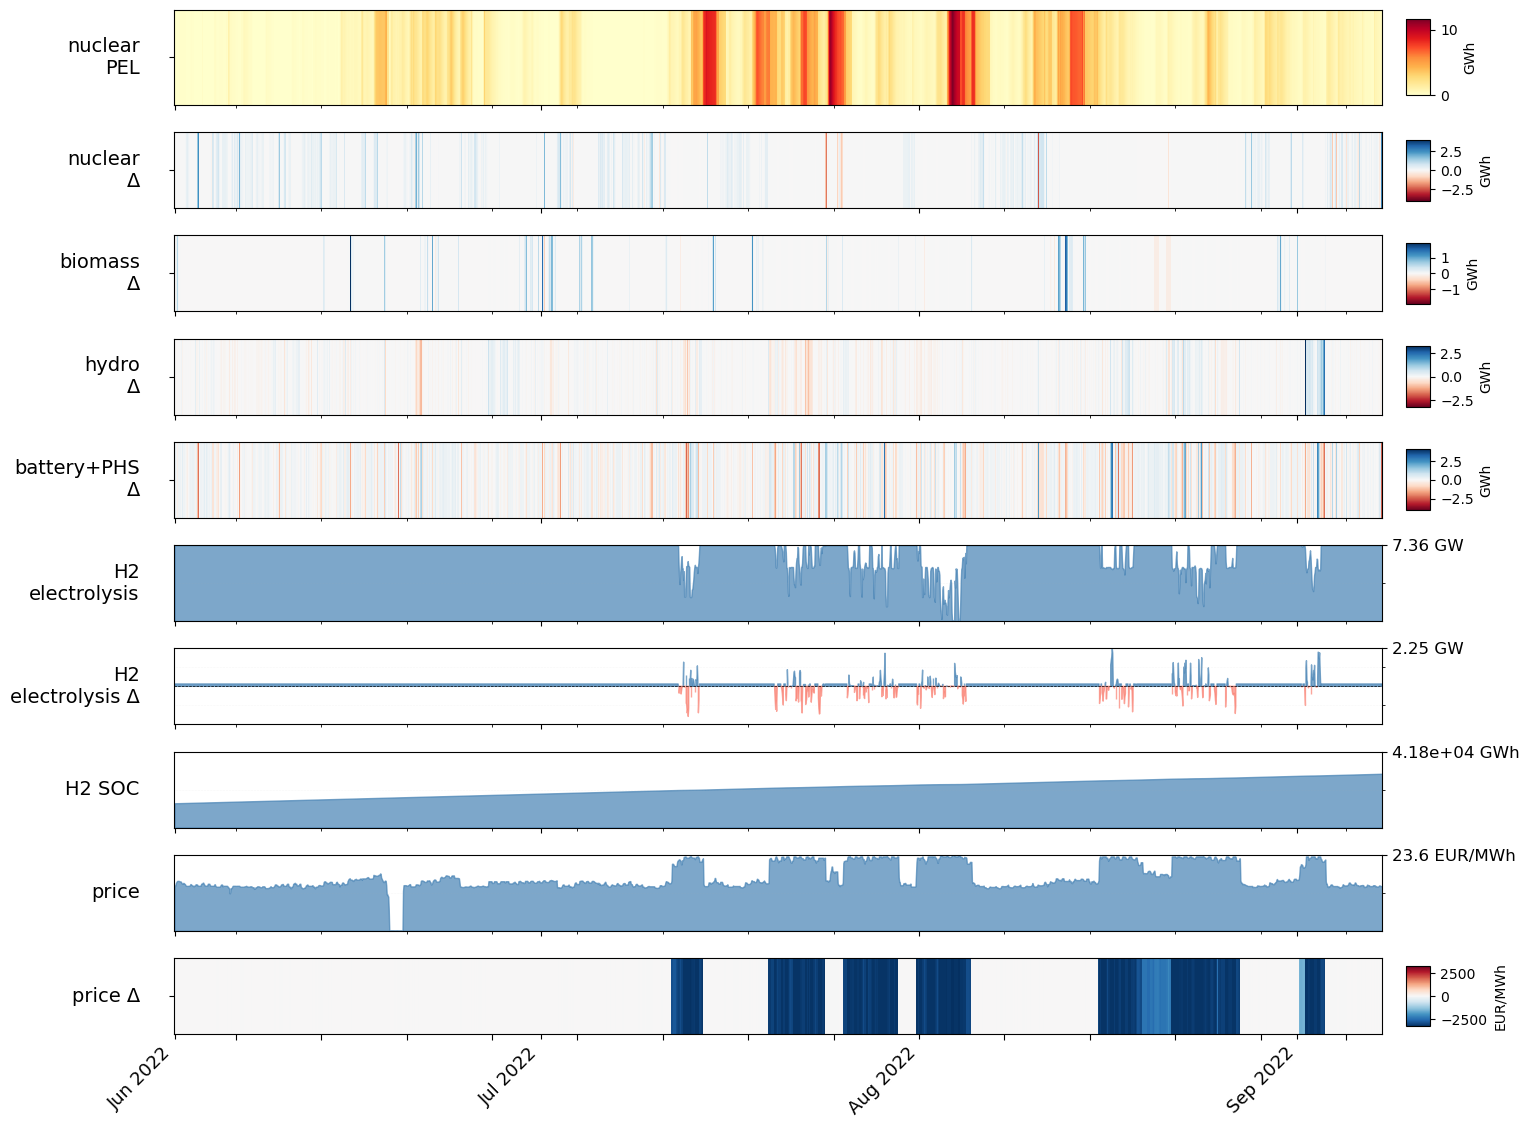

In [52]:
# Damage scenario — H2 electrolysis, SOC, price with diffs
base = "dis"
scen = "cap_op"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={
        "nuclear": "nuclear",
        "biomass": "biomass",
        "hydro":   "hydro",
        # "battery": "battery",
        # "PHS": "PHS",
        "battery+PHS": ["battery","PHS"]
        # "ror": "ror",
        # "solar+wind+ror": ["solar","solar-hsat",'offwind-ac','offwind-dc','onwind', 'ror']
    },
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_nuc"],
            "cmap": "YlOrRd", "multiplier": 1e-3, "unit": "GWh", "vmax_group": "nuclear",
            },
        "\u0394": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            # "vmax_group": "nuclear", 
            "row_height": 1.2,
        },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis \u0394": {
            "type": "direct", "data": d["elec_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        # "H2 SOC \u0394": {
        #     "type": "direct", "data": d["soc_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        "price": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-06-01", f"{YEAR}-09-07"),
    show_day_ticks=False,
    title=None,
    fontsize=14,
    label_gap=25,
)

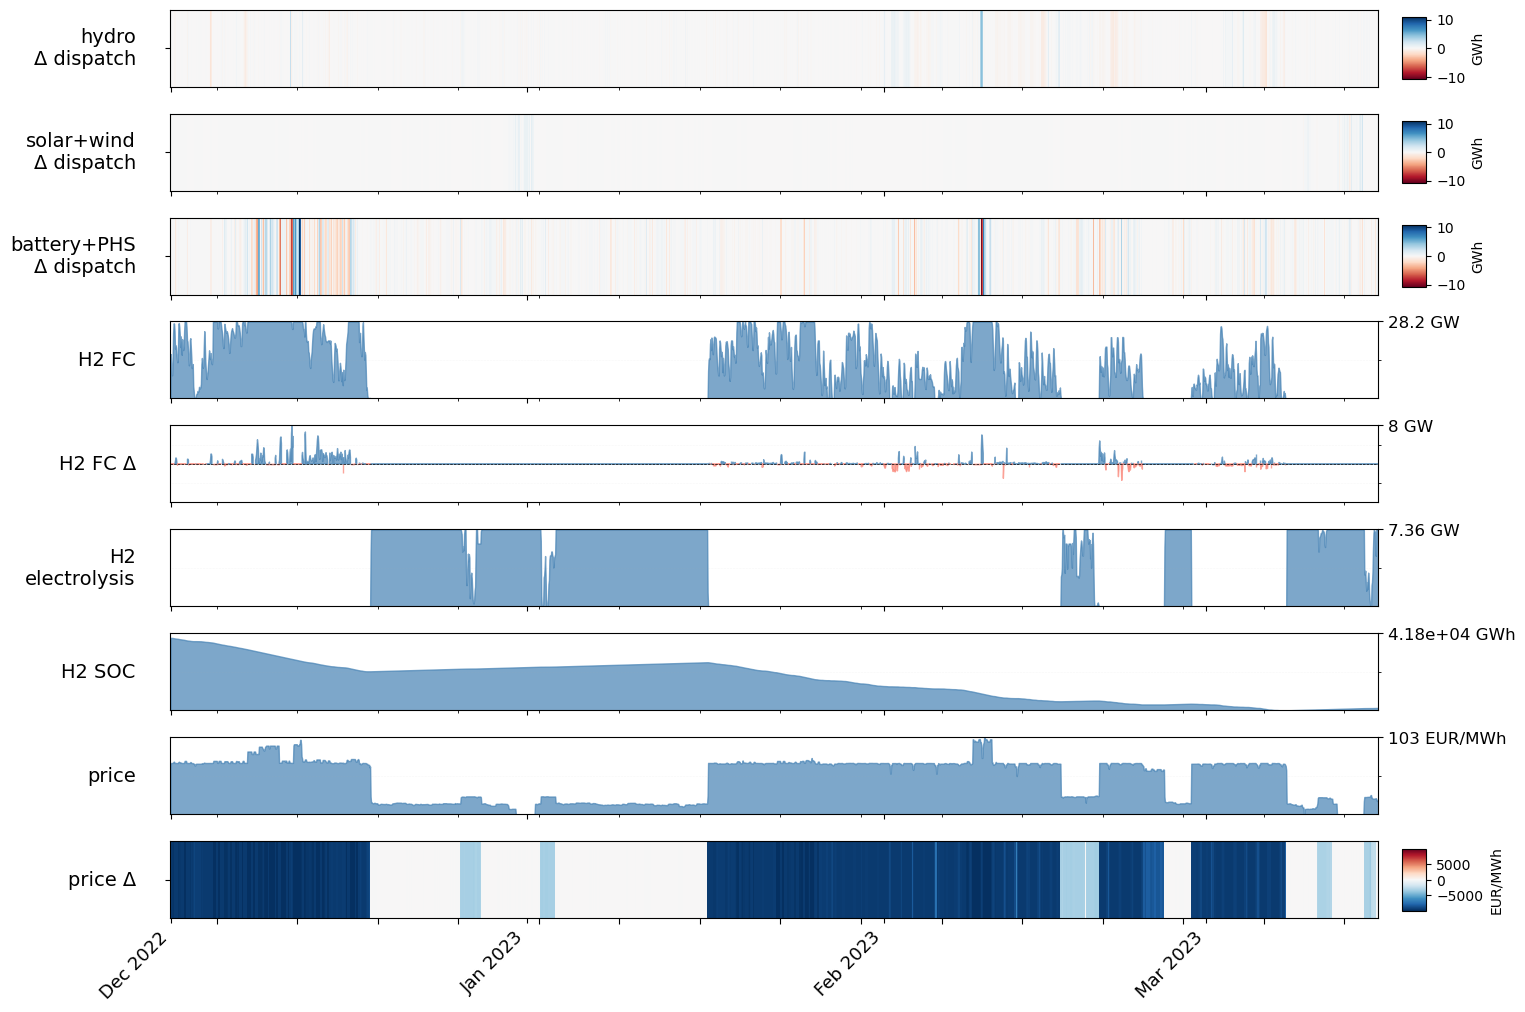

In [54]:
# Winter: hydro/solar/wind/storage with H2 and price diffs
base = "dis"
scen = "cap_op"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={
        # "nuclear": "nuclear",
        # "biomass": "biomass",
        "hydro":       "hydro",
        "solar+wind":  ["solar", "solar-hsat", "offwind-ac", "offwind-dc", "onwind"],
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        # "load shedding": {
        #     "type": "direct", "data": d["ls_df"],
        #     "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        # },
        "\u0394 dispatch": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
            "vmax_group": "nuclear", "row_height": 1.2,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        # "H2 SOC \u0394": {
        #     "type": "direct", "data": d["soc_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        "price": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-12-01", f"{YEAR+1}-03-15"),
    title=None,
    fontsize=14,
    label_gap=25,
)

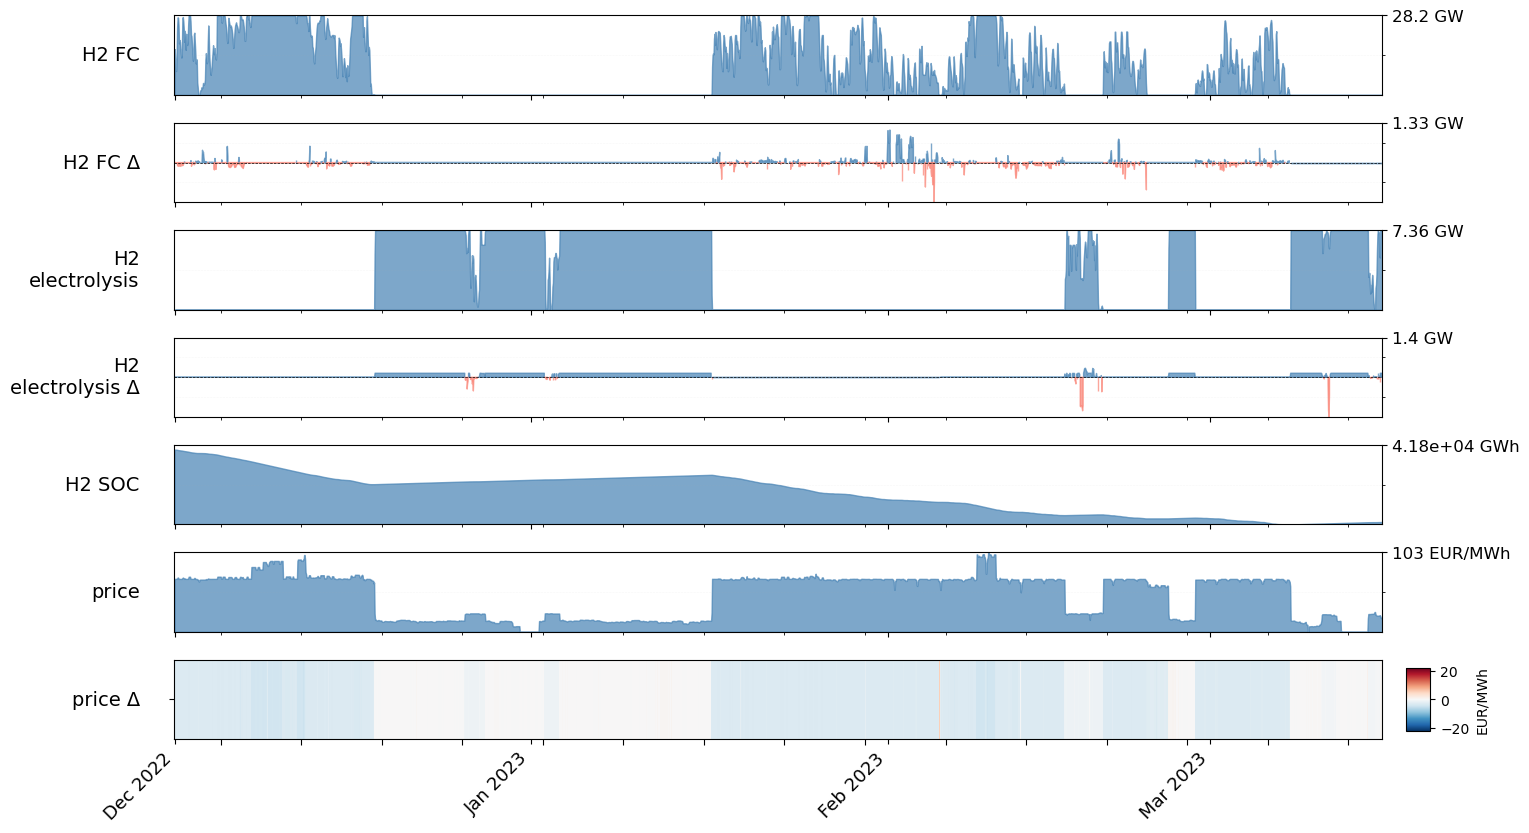

In [36]:
# Winter: hydro/solar/wind/storage with H2 and price diffs
base = "base_dis"
scen = "cap_op"

d = prepare_combo_data(base, scen, nc=nc, scenarios=scenarios)

fig, axes = plot_combination_profile(
    carrier_groups={
        "hydro":       "hydro",
        "solar+wind":  ["solar", "solar-hsat", "offwind-ac", "offwind-dc", "onwind"],
        "battery+PHS": ["battery", "PHS"],
    },
    components={
        # "load shedding": {
        #     "type": "direct", "data": d["ls_df"],
        #     "cmap": "Purples", "multiplier": 1e-3, "unit": "GWh",
        # },
        # "\u0394 dispatch": {
        #     "type": "ts_diff", "data": d["ts_diff"], "network": scen,
        #     "cmap": "RdBu", "symmetric": True, "multiplier": 1e-3, "unit": "GWh",
        #     "vmax_group": "nuclear", "row_height": 1.2,
        # },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 FC \u0394": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2\nelectrolysis \u0394": {
            "type": "direct", "data": d["elec_diff_df"],
            "render": "area", "symmetric": True,
            "color": "steelblue", "neg_color": "salmon",
            "multiplier": 1e-3, "unit": "GW", "row_height": 1.2,
        },
        "H2 SOC": {
            "type": "direct", "data": d["soc_scen"],
            "render": "area", "symmetric": False,
            "vmax": d["h2_e_nom_by_bus"] * 1e-3,
            "multiplier": 1e-3, "unit": "GWh", "color": "steelblue", "row_height": 1.2,
        },
        # "H2 SOC \u0394": {
        #     "type": "direct", "data": d["soc_diff_df"],
        #     "render": "area", "symmetric": True,
        #     "multiplier": 1e-3, "unit": "GWh",
        #     "color": "steelblue", "neg_color": "salmon", "row_height": 1.2,
        # },
        "price": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "EUR/MWh", "row_height": 1.2,
        },
        "price \u0394": {
            "type": "direct", "data": d["price_diff"],
            "render": "heatmap", "cmap": "RdBu_r",
            "symmetric": True, "unit": "EUR/MWh", "row_height": 1.2,
        },
    },
    aggregate_buses=True,
    date_range=(f"{YEAR}-12-01", f"{YEAR+1}-03-15"),
    title=None,
    fontsize=14,
    label_gap=25,
)